# **Acne Segmentation - CLIPSeg Prompt Experiment**

## **Imports**

In [1]:
import os
import gc
import random
from pathlib import Path

import cv2
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode
from tqdm import tqdm
from transformers import CLIPSegProcessor, CLIPSegForImageSegmentation

## **Configuration**

In [2]:
ROOT = "/kaggle/input/datasets/karmagames/acne04-v2/"

MASKS_DIR = os.path.join(ROOT, "gt_masks/gt_masks")

# For a baseline experiment, which involves only augmentations
IMAGES_DIR = os.path.join(ROOT, "img_data/img_data")

# For a ROI experiment, which involves extraction of facial ROI region
# IMAGES_DIR = os.path.join(ROOT, "clean_roi/clean_roi")

# For a CLAHE & ITA experiment, which involves CLAHE transform, conditioned on ITA
# IMAGES_DIR = os.path.join(ROOT, "images_acne_preprocess/images_acne_preprocess")

IMAGE_SIZE = 2000
BATCH_SIZE = 2
RANDOM_STATE = 42
THRESHOLD = 0.3
CLIPSEG_MODEL_NAME = "CIDAS/clipseg-rd64-refined"

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True

print("Device:", DEVICE)

Device: cpu


## **Augmentations & Dataset**

In [3]:
class RandomGamma:
    def __init__(self, gamma_range=(0.8, 1.25), p=0.5):
        self.gamma_range = gamma_range
        self.p = p

    def __call__(self, img):
        if random.random() < self.p:
            gamma = random.uniform(*self.gamma_range)
            return TF.adjust_gamma(img, gamma)
        return img


class RandomGaussianBlur:
    def __init__(self, radius_range=(0.1, 0.8), p=0.2):
        self.radius_range = radius_range
        self.p = p

    def __call__(self, img):
        if random.random() < self.p:
            sigma = random.uniform(*self.radius_range)
            return TF.gaussian_blur(img, kernel_size=3, sigma=sigma)
        return img


class AcneSegDataset(Dataset):
    def __init__(self, image_paths, images_dir, masks_dir, image_size=512, train=False):
        self.image_paths = image_paths
        self.images_dir = Path(images_dir)
        self.masks_dir = Path(masks_dir)
        self.image_size = image_size
        self.train = train

        self.color_aug = transforms.Compose([
            transforms.ColorJitter(brightness=0.20, contrast=0.20, saturation=0.08, hue=0.015),
            RandomGamma(gamma_range=(0.80, 1.25), p=0.50),
            RandomGaussianBlur(radius_range=(0.1, 0.8), p=0.20),
        ])

        self.normalize = transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)

    def __len__(self):
        return len(self.image_paths)

    def _get_image_path(self, img_item):
        img_item = Path(img_item)
        return img_item if img_item.exists() else self.images_dir / img_item.name

    def _get_mask_path(self, img_path):
        return self.masks_dir / f"{Path(img_path).stem}.png"

    def __getitem__(self, idx):
        img_path = self._get_image_path(self.image_paths[idx])
        mask_path = self._get_mask_path(img_path)

        image = cv2.imread(str(img_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

        image = cv2.resize(image, (self.image_size, self.image_size), interpolation=cv2.INTER_AREA)
        mask = cv2.resize(mask, (self.image_size, self.image_size), interpolation=cv2.INTER_NEAREST)

        image = TF.to_pil_image(image)
        mask = TF.to_pil_image(mask)

        if self.train:
            if random.random() < 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask)

            if random.random() < 0.15:
                image = TF.vflip(image)
                mask = TF.vflip(mask)

            angle = random.uniform(-10, 10)
            image = TF.rotate(image, angle, interpolation=InterpolationMode.BILINEAR)
            mask = TF.rotate(mask, angle, interpolation=InterpolationMode.NEAREST)
            image = self.color_aug(image)

        image = self.normalize(TF.to_tensor(image))
        mask = (TF.to_tensor(mask) > 0.5).float()

        return image, mask


def tensor_to_rgb_uint8(img_t, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    image = img_t.detach().cpu().float()
    mean_t = torch.as_tensor(mean, dtype=image.dtype).view(3, 1, 1)
    std_t = torch.as_tensor(std, dtype=image.dtype).view(3, 1, 1)

    image = image * std_t + mean_t
    image = torch.clamp(image, 0, 1)
    image = image.permute(1, 2, 0).numpy()
    return (image * 255).astype(np.uint8)


def denormalize_image(img_t, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    image = img_t.detach().cpu().float()
    mean_t = torch.as_tensor(mean, dtype=image.dtype).view(3, 1, 1)
    std_t = torch.as_tensor(std, dtype=image.dtype).view(3, 1, 1)

    image = image * std_t + mean_t
    image = torch.clamp(image, 0, 1)
    return image.permute(1, 2, 0).numpy()


def compute_metrics_single(pred, gt, eps=1e-8):
    pred = pred.astype(np.float32)
    gt = gt.astype(np.float32)

    intersection = (pred * gt).sum()
    union = pred.sum() + gt.sum() - intersection

    dice = (2 * intersection + eps) / (pred.sum() + gt.sum() + eps)
    iou = (intersection + eps) / (union + eps)
    return dice, iou


def make_error_overlay(image, pred, gt, alpha=0.45):
    pred = pred.astype(bool)
    gt = gt.astype(bool)

    tp = pred & gt
    fp = pred & ~gt
    fn = ~pred & gt

    overlay = image.copy()
    overlay[tp] = (1 - alpha) * overlay[tp] + alpha * np.array([0.0, 1.0, 0.0])
    overlay[fp] = (1 - alpha) * overlay[fp] + alpha * np.array([1.0, 0.0, 0.0])
    overlay[fn] = (1 - alpha) * overlay[fn] + alpha * np.array([0.0, 0.0, 1.0])

    return np.clip(overlay, 0, 1)


## **Data Prepare**

In [4]:
VALID_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

all_image_paths = []
for fname in sorted(os.listdir(IMAGES_DIR)):
    if Path(fname).suffix.lower() not in VALID_EXTS:
        continue

    img_path = os.path.join(IMAGES_DIR, fname)
    mask_path = os.path.join(MASKS_DIR, f"{Path(fname).stem}.png")

    if os.path.exists(mask_path):
        all_image_paths.append(img_path)

train_paths, temp_paths = train_test_split(
    all_image_paths,
    test_size=0.2,
    random_state=RANDOM_STATE,
    shuffle=True,
)

val_paths, test_paths = train_test_split(
    temp_paths,
    test_size=0.5,
    random_state=RANDOM_STATE,
    shuffle=True,
)

print(f"Found {len(all_image_paths)} image-mask pairs")
print("Train:", len(train_paths))
print("Val:", len(val_paths))
print("Test:", len(test_paths))


Found 1204 image-mask pairs
Train: 963
Val: 120
Test: 121


In [5]:
test_ds = AcneSegDataset(
    image_paths=test_paths,
    images_dir=IMAGES_DIR,
    masks_dir=MASKS_DIR,
    image_size=IMAGE_SIZE,
    train=False,
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

images, masks = next(iter(test_loader))
print("Images shape:", images.shape)
print("Masks shape :", masks.shape)
print("Mask values :", masks.min().item(), masks.max().item())


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Images shape: torch.Size([2, 3, 2000, 2000])
Masks shape : torch.Size([2, 1, 2000, 2000])
Mask values : 0.0 1.0


## **CLIPSeg Model**

In [7]:
clipseg_processor = CLIPSegProcessor.from_pretrained(CLIPSEG_MODEL_NAME)
clipseg_model = CLIPSegForImageSegmentation.from_pretrained(CLIPSEG_MODEL_NAME).to(DEVICE)
clipseg_model.eval()


Loading weights:   0%|          | 0/462 [00:00<?, ?it/s]

CLIPSegForImageSegmentation LOAD REPORT from: CIDAS/clipseg-rd64-refined
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
clip.vision_model.embeddings.position_ids | UNEXPECTED |  | 
clip.text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CLIPSegForImageSegmentation(
  (clip): CLIPSegModel(
    (text_model): CLIPSegTextTransformer(
      (embeddings): CLIPSegTextEmbeddings(
        (token_embedding): Embedding(49408, 512)
        (position_embedding): Embedding(77, 512)
      )
      (encoder): CLIPSegEncoder(
        (layers): ModuleList(
          (0-11): 12 x CLIPSegEncoderLayer(
            (self_attn): CLIPSegAttention(
              (k_proj): Linear(in_features=512, out_features=512, bias=True)
              (v_proj): Linear(in_features=512, out_features=512, bias=True)
              (q_proj): Linear(in_features=512, out_features=512, bias=True)
              (out_proj): Linear(in_features=512, out_features=512, bias=True)
            )
            (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
            (mlp): CLIPSegMLP(
              (activation_fn): QuickGELUActivation()
              (fc1): Linear(in_features=512, out_features=2048, bias=True)
              (fc2): Linear(in_features=20

## **Inference functions**

In [8]:
@torch.no_grad()
def clipseg_predict_single(model, processor, image_rgb, prompt, out_size):
    inputs = processor(
        text=[prompt],
        images=[image_rgb],
        padding=True,
        return_tensors="pt",
    ).to(DEVICE)

    outputs = model(**inputs)
    logits = outputs.logits

    if logits.ndim == 3:
        logits = logits.unsqueeze(1)

    logits = F.interpolate(
        logits,
        size=out_size,
        mode="bilinear",
        align_corners=False,
    )

    probs = torch.sigmoid(logits)[0, 0].detach().cpu().numpy()
    return probs


@torch.no_grad()
def evaluate_clipseg_text_prompt(model, processor, loader, prompt, threshold=0.5, eps=1e-8):
    model.eval()

    total_tp = 0.0
    total_fp = 0.0
    total_fn = 0.0
    total_tn = 0.0

    all_images = []
    all_masks = []
    all_preds = []
    all_probs = []

    for images, masks in tqdm(loader, desc=f"CLIPSeg eval: {prompt}"):
        for i in range(images.shape[0]):
            image_t = images[i]
            mask_t = masks[i]

            image_rgb = tensor_to_rgb_uint8(image_t)
            gt = (mask_t[0].cpu().numpy() > 0.5).astype(np.uint8)

            probs = clipseg_predict_single(
                model=model,
                processor=processor,
                image_rgb=image_rgb,
                prompt=prompt,
                out_size=gt.shape,
            )
            pred = (probs > threshold).astype(np.uint8)

            tp = (pred * gt).sum()
            fp = (pred * (1 - gt)).sum()
            fn = ((1 - pred) * gt).sum()
            tn = ((1 - pred) * (1 - gt)).sum()

            total_tp += tp
            total_fp += fp
            total_fn += fn
            total_tn += tn

            all_images.append(image_t.cpu())
            all_masks.append(mask_t.cpu())
            all_preds.append(torch.from_numpy(pred[None, ...]).float())
            all_probs.append(torch.from_numpy(probs[None, ...]).float())

    precision = total_tp / (total_tp + total_fp + eps)
    recall = total_tp / (total_tp + total_fn + eps)
    iou = total_tp / (total_tp + total_fp + total_fn + eps)
    dice = (2 * total_tp) / (2 * total_tp + total_fp + total_fn + eps)
    accuracy = (total_tp + total_tn) / (total_tp + total_tn + total_fp + total_fn + eps)

    return {
        "prompt": prompt,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "iou": iou,
        "dice": dice,
        "imgs": torch.stack(all_images),
        "masks": torch.stack(all_masks),
        "preds": torch.stack(all_preds),
        "probs": torch.stack(all_probs),
    }


def visualize_predictions_grid(images, masks, preds, n=6):
    n = min(n, len(images))
    fig, axes = plt.subplots(n, 4, figsize=(18, 4 * n))

    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(n):
        image = denormalize_image(images[i])
        gt = masks[i, 0].numpy()
        pred = preds[i, 0].numpy()

        dice, iou = compute_metrics_single(pred, gt)
        overlay = make_error_overlay(image, pred, gt)

        axes[i, 0].imshow(image)
        axes[i, 0].set_title("Image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(gt, cmap="gray")
        axes[i, 1].set_title("Ground Truth")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(pred, cmap="gray")
        axes[i, 2].set_title(f"Prediction\nDice={dice:.3f} IoU={iou:.3f}")
        axes[i, 2].axis("off")

        axes[i, 3].imshow(overlay)
        axes[i, 3].set_title("Overlay\nGreen=TP Red=FP Blue=FN")
        axes[i, 3].axis("off")

    plt.tight_layout()
    plt.show()

## **Prompt Evaluation**

In [9]:
# prompts = [
#     "acne",
#     "pimple",
#     "inflamed pimple",
#     "red acne spot",
#     "skin lesion",
#     "acne or pimple or inflamed pimple or red acne spot or skin lesion",
# ]

prompts = [
    "small red raised bumps with irregular shape on facial skin",
    "tiny inflamed red spots scattered on skin",
    "small red bumps with slightly darker center",
    "clusters of tiny red circular spots on face",
    "irregular small red lesions on skin surface",
]

all_clipseg_results = {}

for p in prompts:
    res = evaluate_clipseg_text_prompt(
        model=clipseg_model,
        processor=clipseg_processor,
        loader=test_loader,
        prompt=p,
        threshold=0.3,
    )

    print(
        p,
        {
            "accuracy": round(res["accuracy"], 4),
            "precision": round(res["precision"], 4),
            "recall": round(res["recall"], 4),
            "iou": round(res["iou"], 4),
            "dice": round(res["dice"], 4),
        }
    )

    metrics = {k: res[k] for k in ["accuracy", "precision", "recall", "iou", "dice"]}
    all_clipseg_results[p] = metrics

    del res
    gc.collect()
    torch.cuda.empty_cache()

CLIPSeg eval: small red raised bumps with irregular shape on facial skin: 100%|██████████| 61/61 [02:59<00:00,  2.95s/it]


small red raised bumps with irregular shape on facial skin {'accuracy': np.float64(0.9661), 'precision': np.float64(0.0267), 'recall': np.float64(0.15), 'iou': np.float64(0.0232), 'dice': np.float64(0.0453)}


CLIPSeg eval: tiny inflamed red spots scattered on skin: 100%|██████████| 61/61 [02:48<00:00,  2.75s/it]


tiny inflamed red spots scattered on skin {'accuracy': np.float64(0.9943), 'precision': np.float64(0.0), 'recall': np.float64(0.0), 'iou': np.float64(0.0), 'dice': np.float64(0.0)}


CLIPSeg eval: small red bumps with slightly darker center: 100%|██████████| 61/61 [02:45<00:00,  2.71s/it]


small red bumps with slightly darker center {'accuracy': np.float64(0.9934), 'precision': np.float64(0.0247), 'recall': np.float64(0.0062), 'iou': np.float64(0.005), 'dice': np.float64(0.0099)}


CLIPSeg eval: clusters of tiny red circular spots on face: 100%|██████████| 61/61 [02:46<00:00,  2.73s/it]


clusters of tiny red circular spots on face {'accuracy': np.float64(0.7829), 'precision': np.float64(0.0169), 'recall': np.float64(0.69), 'iou': np.float64(0.0167), 'dice': np.float64(0.0329)}


CLIPSeg eval: irregular small red lesions on skin surface: 100%|██████████| 61/61 [02:49<00:00,  2.78s/it]


irregular small red lesions on skin surface {'accuracy': np.float64(0.9942), 'precision': np.float64(0.0034), 'recall': np.float64(0.0003), 'iou': np.float64(0.0003), 'dice': np.float64(0.0005)}


In [10]:
best_prompt = max(all_clipseg_results, key=lambda k: all_clipseg_results[k]["dice"])
best_clipseg_res = all_clipseg_results[best_prompt]

print("Best prompt:", best_prompt)
print({
    "accuracy": round(best_clipseg_res["accuracy"], 4),
    "precision": round(best_clipseg_res["precision"], 4),
    "recall": round(best_clipseg_res["recall"], 4),
    "iou": round(best_clipseg_res["iou"], 4),
    "dice": round(best_clipseg_res["dice"], 4),
})

Best prompt: small red raised bumps with irregular shape on facial skin
{'accuracy': np.float64(0.9661), 'precision': np.float64(0.0267), 'recall': np.float64(0.15), 'iou': np.float64(0.0232), 'dice': np.float64(0.0453)}


## **Best Prompt Visualization**

CLIPSeg eval: small red raised bumps with irregular shape on facial skin: 100%|██████████| 61/61 [02:55<00:00,  2.87s/it]


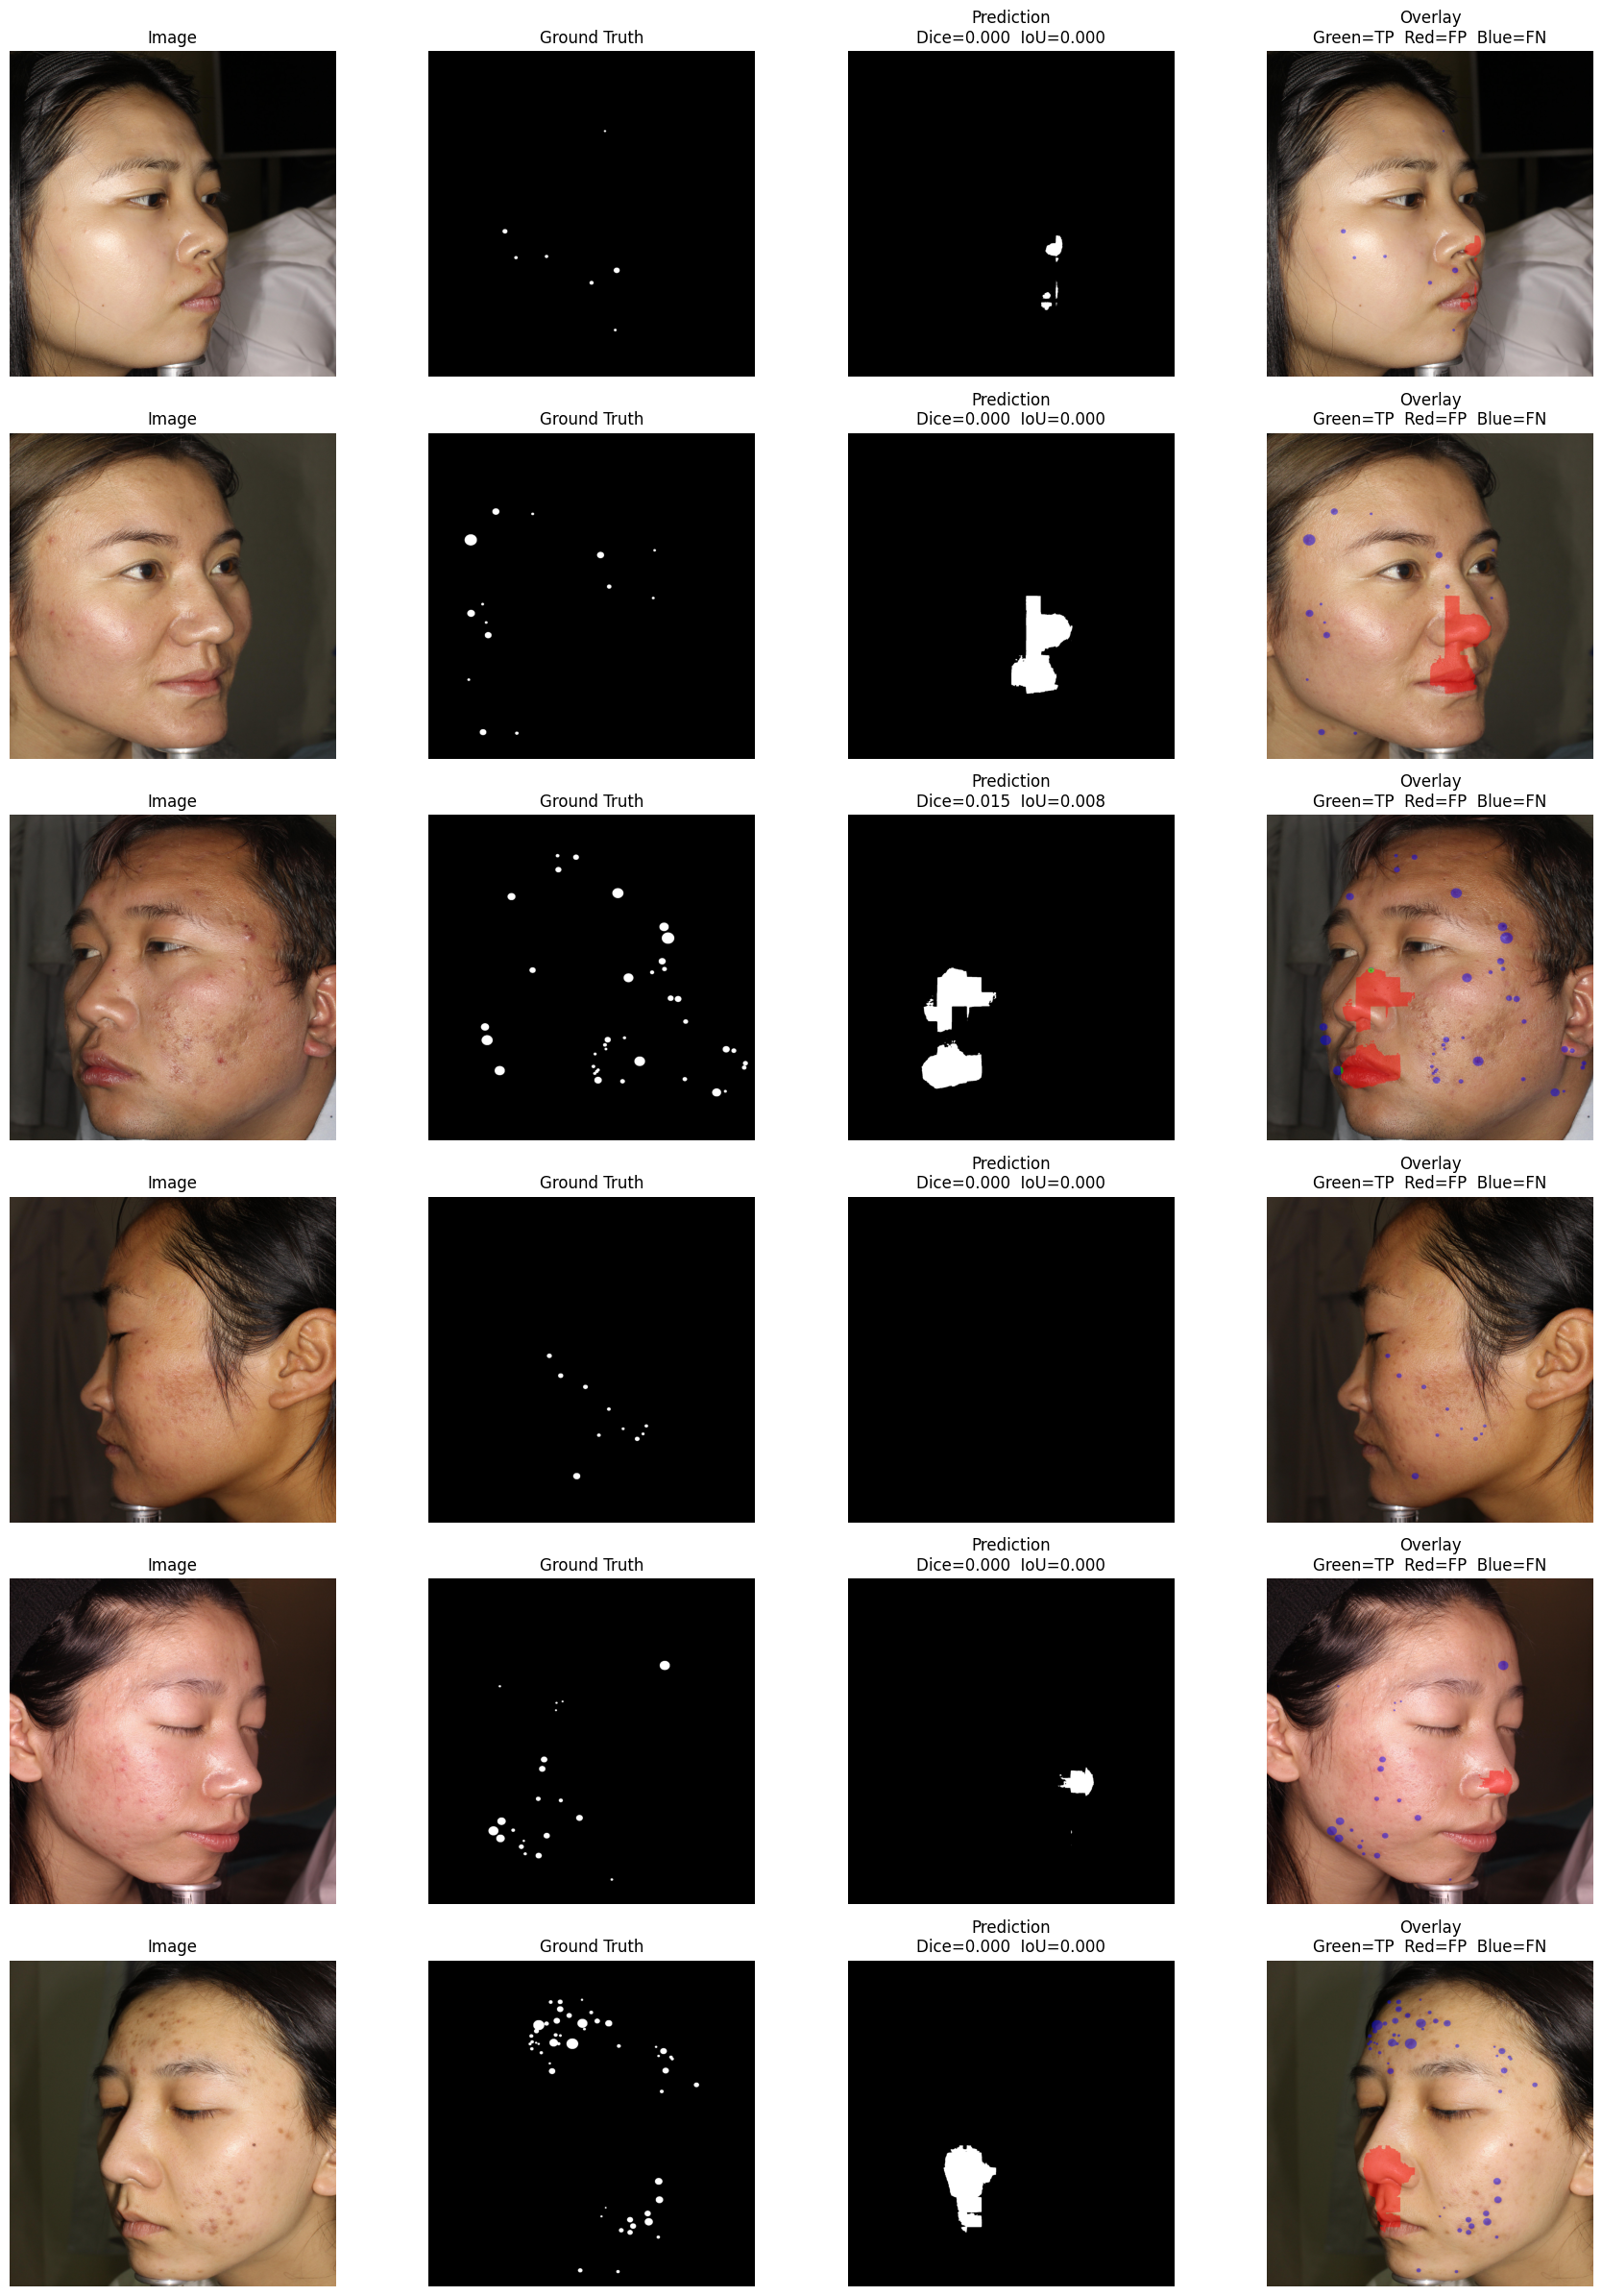

In [11]:
clipseg_res = evaluate_clipseg_text_prompt(
    model=clipseg_model,
    processor=clipseg_processor,
    loader=test_loader,
    prompt="small red raised bumps with irregular shape on facial skin",
    threshold=0.3,
)

visualize_predictions_grid(
    clipseg_res["imgs"],
    clipseg_res["masks"],
    clipseg_res["preds"],
    n=6
)